# Initial Investigations into Anomalous Pressure Gradients & EPEs
*Written by: Adam Morgan*

*Last Updated March 2, 2026*

In [1]:
import cftime
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy.stats as spstats
import xarray as xr

# Homemade routines
from ep_processing import *

Loading the data...

In [2]:
my_base_path = "~/Documents/research/experiment-outputs/{experiment_name}/{runid}/"
my_generic_file_path = "_day_CanESM5-1_{experiment_name}_r1i1p1f1_gn_{year}0101-{year}1231.nc"
my_pr_file_path = "pr" + my_generic_file_path
my_ps_file_path = "ps" + my_generic_file_path

my_experiment_name = "amip"
my_runid = "agm-amip-test"
year_start = 2003
year_end = 2008 + 1
year_range = range(year_start, year_end)

In [3]:
# Daily surface pressure (obtained by post-processing/downsampling model outputs)
ds_ps_daily = get_ds(
        "ps",
        my_runid,
        my_experiment_name,
        year_range,
        base_path = my_base_path,
        file_path = my_ps_file_path,
)

# Daily precipitation 
ds_pr_daily = get_ds(
        "pr",
        my_runid,
        my_experiment_name,
        year_range,
        base_path = my_base_path,
        file_path = my_pr_file_path,
)

Determine the surface pressure gradient's magnitude as a function of space and time with a helper method I wrote: 

In [4]:
da_grad_ps = get_abs_horiz_gradient(ds_ps_daily.ps)

In [5]:
da_grad_ps.units

'Pa/km'

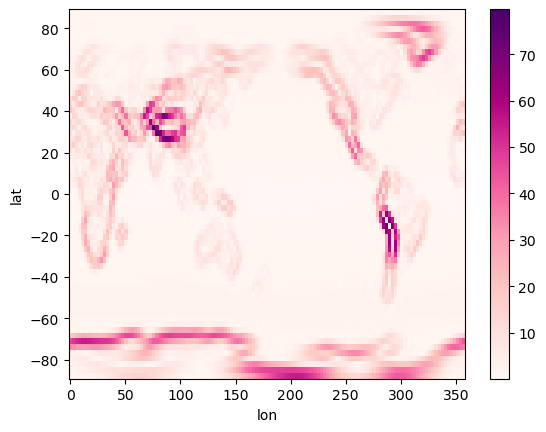

In [37]:
da_grad_ps.mean(dim = "time").plot(
    cmap = "RdPu",
)
plt.show()

We see very large spikes in $|\nabla p_S|$ over land, especially over mountainous regions. Accordingly, we define our anomaly of $|\nabla p_S|$ as a *relative* difference. 

# Case 1: Plain Climatology

In [7]:
grad_ps_anom_as_temporal_list = []

da_grad_ps_temporal_mean = da_grad_ps.mean(dim = "time")

for year in year_range:
    day_of_epe = select_fixed_year(ds_pr_daily.pr, year).idxmax(dim = "time")
    anom_current_year = (
        (
            da_grad_ps.sel(time = day_of_epe, method = "ffill") - da_grad_ps_temporal_mean
        ) / da_grad_ps_temporal_mean
    )
    grad_ps_anom_as_temporal_list.append(anom_current_year)

da_grad_ps_anom = xr.DataArray(
        data = grad_ps_anom_as_temporal_list,
        dims = ["time", "lat", "lon"],
        coords = dict(
            lon = da_grad_ps.lon.to_numpy(),
            lat = da_grad_ps.lat.to_numpy(),
            time = [year for year in year_range],
        ),
)

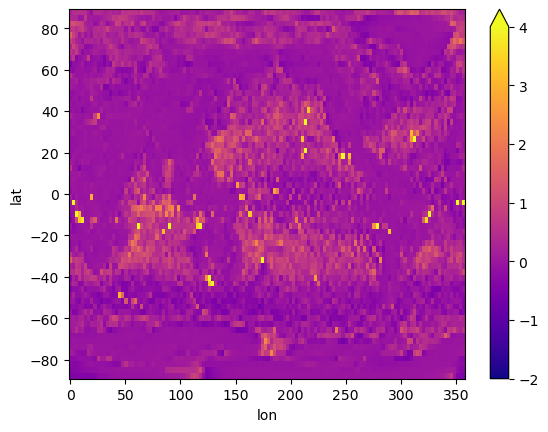

In [38]:
anom_threshold = 4. # set to None if you want to see outliers 
da_grad_ps_anom.mean(dim = "time").plot(
    vmin = -0.5 * anom_threshold if anom_threshold else None,
    vmax = anom_threshold, 
    cmap = "plasma",
)
plt.show()

Aside from some (very) hot spots sprinkled across the map, we see there's a lot of positive anomalies over the oceans (especially stormy areas like the Indian Ocean). The "quiet zone" in the Pacific is roughly aligned with the low-precipitation eastern Pacific. Unfortunately, we don't see much interesting happening over land: this may indicate that we need to use a more sophisticated land vs. sea anomaly. **In a nutshell, it appears that anomalies are approximately spatially correlated with high-precipitation areas!**

For further analysis, it's also helpful to store the anomalies as a flattened array. This allows us to treat the anomalies at each grid cell and each year as samples of some random variable. 

In [9]:
grad_ps_anom_as_array = da_grad_ps_anom.to_numpy().flatten()

Playing with the above code reveals that there are some very large anomalies sprinkled into our sample. Let's see how big these are: 

In [10]:
np.amax(grad_ps_anom_as_array)

np.float32(75.17734)

In [11]:
np.amin(grad_ps_anom_as_array)

np.float32(-0.9923655)

The minimum seems fine, but the maximum appears to be way bigger than is reasonable! This suggests we may have to do some further postprocessing to remove "outliers". Some informal testing I've done suggests this doesn't radically modify the statistics. 

We can fit skew-Laplace or Jones-Faddy skew-$t$ distributions to these anomalies. 

These particular choices of distribution were guessed by examining the raw histogram and empirical CDF. I also fit Gumbel, skew-Cauchy, Johnson SB, Burr-3, Burr-12, Fisk, Kappa4, Landau, Maxwell, Mielke, Rice, and skew-normal distributions to the data, but generally this did much worse. 

Skew-Laplace seemed to reproduce the tails (viewed via the CDF) much better than any other option, but it did not describe the distribution for small anomalies well. Jones-Faddy skew-$t$ had no trouble with small anomalies and the error in the tails is not too bad. Additionally, Jones-Faddy skew-$t$ produces the smallest $L^2$ error in fitted vs. empirical CDF I observed, and its $L^{\infty}$ error is better than skew-Laplace owing to the issues with small anomalies.

Skew-Cauchy, interestingly, gave the least amount of $L^{\infty}$ error in the CDF, but the $L^2$ error was poor and qualitatively the fit seemed suboptimal and I decided not to pursue it further. 

In [12]:
anom_grad_ps_ecdf = spstats.ecdf(grad_ps_anom_as_array).cdf

In [13]:
skew_laplace_res = spstats.laplace_asymmetric.fit(grad_ps_anom_as_array)
kappa, loc, scale = skew_laplace_res
skew_laplace_dist = spstats.laplace_asymmetric(kappa = kappa, loc = loc,scale = scale)

In [14]:
jf_skew_t_res = spstats.jf_skew_t.fit(grad_ps_anom_as_array)
a, b, loc, scale = jf_skew_t_res
jf_skew_t_dist = spstats.jf_skew_t(a = a, b = b, loc = loc, scale = scale)

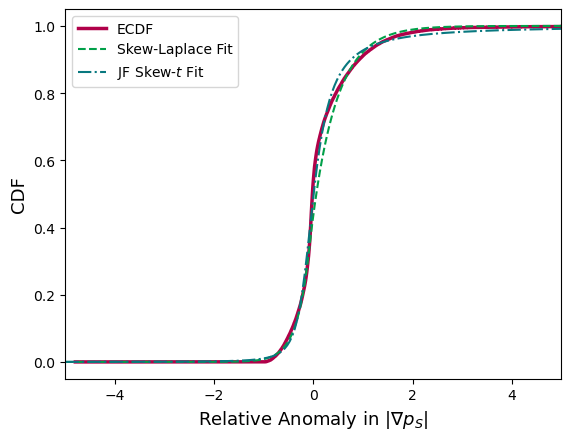

In [15]:
fig, ax = plt.subplots()

x = np.linspace(-5, 5, num=200)
anom_grad_ps_ecdf.plot(
    ax,
    color = "xkcd:raspberry", 
    label = "ECDF",
    linewidth = 2.5,
)
ax.plot(
    x, 
    skew_laplace_dist.cdf(x), 
    color = "xkcd:emerald",
    linestyle = "dashed", 
    label = "Skew-Laplace Fit",
    linewidth = 1.5,
)
ax.plot(
    x, 
    jf_skew_t_dist.cdf(x), 
    color = "xkcd:deep aqua",
    linestyle = "dashdot", 
    label = "JF Skew-$t$ Fit",
    linewidth = 1.5,
)

plt.xlabel(r"Relative Anomaly in $|\nabla p_S|$", fontsize = "13")
plt.ylabel(r"CDF", fontsize = "13")
plt.legend()
plt.xlim(-5, 5)

plt.show()

Now for some naive goodness-of-fit tests using the CDF. The $L^2$ distance between the empirical and fitted CDFs is

In [16]:
np.linalg.norm(skew_laplace_dist.cdf(x) - anom_grad_ps_ecdf.evaluate(x), ord = 2)

np.float64(0.2776251773729905)

In [17]:
np.linalg.norm(jf_skew_t_dist.cdf(x) - anom_grad_ps_ecdf.evaluate(x), ord = 2)

np.float64(0.18593191365471715)

while the $L^{\infty}$ distance is 

In [18]:
np.amax(np.abs(skew_laplace_dist.cdf(x) - anom_grad_ps_ecdf.evaluate(x)))

np.float64(0.11784641522470651)

In [19]:
np.amax(np.abs(jf_skew_t_dist.cdf(x) - anom_grad_ps_ecdf.evaluate(x)))

np.float64(0.057146040343641236)

To make sure the anomalies we're seeing are actually associated with EPEs and not occurring "by chance alone", we can compare them to the anomalies taken on *uniformly random days*. 

In [39]:
np.random.seed(32)
rng = np.random.default_rng()
random_date_indices = rng.integers(
    low = 0, 
    high = len(da_grad_ps.time), 
    size = (len(da_grad_ps.lat) , len(da_grad_ps.lon)),
)  

In [21]:
random_dates = xr.DataArray(
    data = [da_grad_ps.time[random_date_index] for random_date_index in random_date_indices],
    dims = ["lat", "lon"],
    coords = dict(
            lon = da_grad_ps.lon.to_numpy(),
            lat = da_grad_ps.lat.to_numpy(),
    ),
)

In [22]:
da_grad_ps_random_dates = da_grad_ps.sel(time = random_dates)

In [23]:
da_grad_ps_anom_random_dates = (da_grad_ps_random_dates - da_grad_ps_temporal_mean) / da_grad_ps_temporal_mean

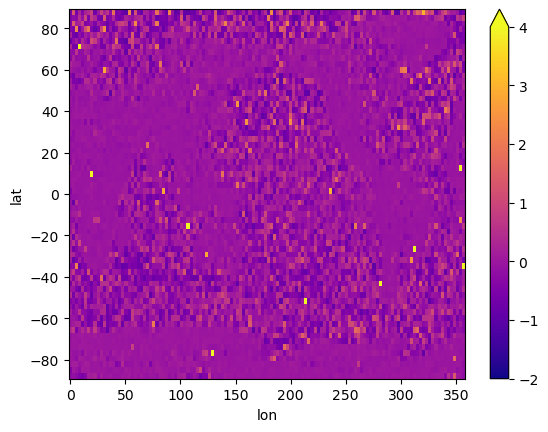

In [24]:
da_grad_ps_anom_random_dates.plot(
    vmin = -0.5 * anom_threshold if anom_threshold else None,
    vmax = anom_threshold, 
    cmap = "plasma",
)
plt.show()

Aside from the land-sea split we saw earlier, this plot looks like "pure noise". That is, at the level of visual inspection I can see no structure in this data, and certainly no correlation with high-precip. areas. This is at odds with what we observed for the anomalies on EPE days! 

Now, let's compare the ECDF of the random day anomalies vs. the ECDF of the EPE anomalies. 

In [25]:
grad_ps_anom_random_dates_as_array = da_grad_ps_anom_random_dates.to_numpy().flatten()
anom_grad_ps_random_dates_ecdf = spstats.ecdf(grad_ps_anom_random_dates_as_array).cdf

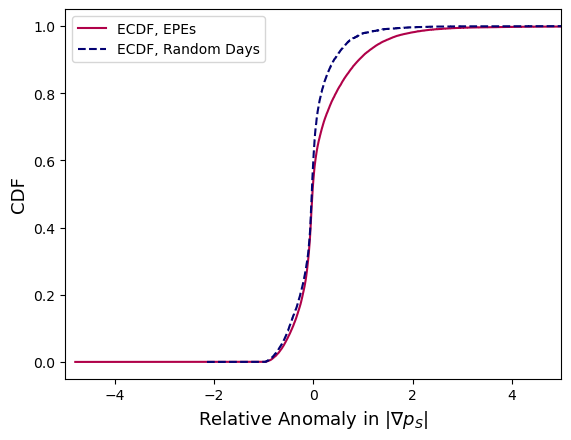

In [26]:
fig, ax = plt.subplots()

x = np.linspace(-5, 5, num=200)
anom_grad_ps_ecdf.plot(
    ax,
    color = "xkcd:raspberry", 
    label = "ECDF, EPEs",
)
anom_grad_ps_random_dates_ecdf.plot(
    ax, 
    color = "xkcd:deep blue",
    label = "ECDF, Random Days",
    linestyle="dashed",
)

plt.xlabel(r"Relative Anomaly in $|\nabla p_S|$", fontsize = "13")
plt.ylabel(r"CDF", fontsize = "13")
plt.legend()
plt.xlim(-5, 5)

plt.show()

In [27]:
np.linalg.norm(anom_grad_ps_random_dates_ecdf.evaluate(x) - anom_grad_ps_ecdf.evaluate(x), ord = 2)

np.float64(0.4794971382073724)

In [28]:
np.amax(np.abs(anom_grad_ps_random_dates_ecdf.evaluate(x) - anom_grad_ps_ecdf.evaluate(x)))

np.float64(0.11444091796875)

We see that the EPE anomalies have a much thicker right-hand side tail than the randomly selected anomalies! This supports the hypothesis that EPEs are correlated with anomalously large pressure gradients. 

## Case 2: Precipitating-Day-Only Climatology

In [29]:
precip_threshold = 1./86400.
epe = get_mean_annual_max(ds_pr_daily, "pr")
epe = epe.where(epe >= precip_threshold, 0.)

In [30]:
def discard_dry_cells(da, epe):
    return da.where((epe > 0.).compute(), drop = True) 

In [31]:
da_grad_ps_no_dry = discard_dry_cells(da_grad_ps, epe)
ds_pr_daily_no_dry = discard_dry_cells(ds_pr_daily, epe)

In [32]:
da_grad_ps_pdo_clim = da_grad_ps_no_dry.where(
    ds_pr_daily_no_dry.pr.values > precip_threshold,
).mean(
    dim = "time",
    skipna = True,
)

In [33]:
grad_ps_pdo_anom_as_temporal_list = []
for year in year_range:
    day_of_epe = select_fixed_year(ds_pr_daily.pr, year).idxmax(dim = "time")
    anom_current_year = (
        (
            da_grad_ps_no_dry.sel(time = day_of_epe, method = "ffill") - da_grad_ps_pdo_clim
        ) / da_grad_ps_pdo_clim
    )
    grad_ps_pdo_anom_as_temporal_list.append(anom_current_year)

da_grad_ps_pdo_anom = xr.DataArray(
        data = grad_ps_pdo_anom_as_temporal_list,
        dims = ["time", "lat", "lon"],
        coords = dict(
            lon = da_grad_ps_no_dry.lon.to_numpy(),
            lat = da_grad_ps_no_dry.lat.to_numpy(),
            time = [year for year in year_range],
        ),
)

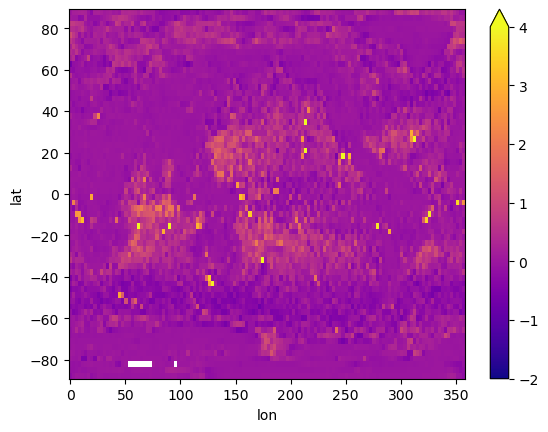

In [34]:
da_grad_ps_pdo_anom.mean(dim="time").plot( vmin = -2, vmax = 4, cmap ="plasma")
plt.show()

This looks very similar to the naive climatology, with the exception of a few grid cells that get ignored because they are "too dry". 

In [35]:
da_grad_ps_pdo_anom_as_array = da_grad_ps_pdo_anom.to_numpy().flatten()
da_grad_ps_pdo_anom_as_array = da_grad_ps_pdo_anom_as_array[~np.isnan(da_grad_ps_pdo_anom_as_array)]
anom_pdo_grad_ps_ecdf = spstats.ecdf(da_grad_ps_pdo_anom_as_array).cdf

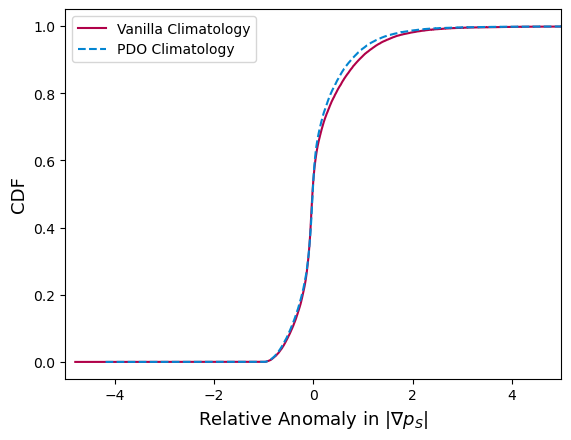

In [36]:
fig, ax = plt.subplots()

x = np.linspace(-5, 5, num=200)
anom_grad_ps_ecdf.plot(
    ax,
    color = "xkcd:raspberry", 
    label = "Vanilla Climatology",
)
anom_pdo_grad_ps_ecdf.plot(
    ax, 
    color = "xkcd:cerulean",
    label = "PDO Climatology",
    linestyle="dashed",
)

plt.xlabel(r"Relative Anomaly in $|\nabla p_S|$", fontsize = "13")
plt.ylabel(r"CDF", fontsize = "13")
plt.legend()
plt.xlim(-5, 5)

plt.show()

Thus the PDO anomaly ECDF is nearly identical to the vanilla one (the vanilla one has a slightly fatter tail).

Altogether it looks like we don't gain much information by looking at precipitating days only! 

## Action Items
- Rigorous, "standard" metrics for goodness-of-fit & comparison of CDFs.
- *Spatial* statistical analysis to examine correlations between anomalous $|\nabla p_S|$ and precipitation, as well as the noisiness we saw for gradient anomalies on random days. Is this best done with EOFs, some spatial correlation measure, or something else?
- How to deal with "outlier" anomalies? Should we just threshold the anomalies at a certain max value? 
- Dealing with land vs. ocean?
- De-seasonalizing: is it even worth it here? Is further de-trending necessary? 